<a href="https://colab.research.google.com/github/Julian6262/the_founder/blob/main/%D0%94%D0%97-17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Используя знания данного урока, и набор данных IMDB вам необходимо:
1. Спроектировать модель классификации отзывов к фильмам с точностью на валидационной выборке более 90%.
2. Показать, что модель способна классифицировать отзывы с вероятностью более 88% на контрольной выборке.

За успешное выполнение задания вы получите 3 балла. Если сможете преодолеть точность 95% на валидационной выборке и/или 93% на контрольной, то получите 4 балла.

Также вы можете получить дополнительно 1 балл, если выполните все предложенные задания в задаче о Титанике (17.1), проанализируете "увеличенную модель" (17.2).

In [ ]:
from keras.datasets import imdb
from keras import layers, regularizers
from keras import models
import numpy as np
from keras.src.optimizers import Adam
import matplotlib.pyplot as plt

In [ ]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

In [ ]:
data = np.concatenate([train_data, test_data])
labels = np.concatenate([train_labels, test_labels])

x_train = data[10000:]
x_test = data[:10000]
y_train = labels[10000:]
y_test = labels[:10000]

In [ ]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

In [ ]:
x_train = vectorize_sequences(x_train)
x_test = vectorize_sequences(x_test)
y_train = y_train.astype('float32')
y_test = y_test.astype('float32')

In [ ]:
model = models.Sequential()
model.add(layers.Dense(12, activation='tanh'))
model.add(layers.Dropout(0.3))
model.add(layers.Dense(8, activation='tanh'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(1, activation='sigmoid'))

opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='mse', metrics=['accuracy'])

In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
500/500 [==============================] - 6s 11ms/step - loss: 0.2045 - accuracy: 0.7345 - val_loss: 0.1514 - val_accuracy: 0.8651
Epoch 2/5
500/500 [==============================] - 3s 7ms/step - loss: 0.1302 - accuracy: 0.8694 - val_loss: 0.1043 - val_accuracy: 0.8900
Epoch 3/5
500/500 [==============================] - 4s 7ms/step - loss: 0.0971 - accuracy: 0.8954 - val_loss: 0.0855 - val_accuracy: 0.8991
Epoch 4/5
500/500 [==============================] - 4s 8ms/step - loss: 0.0804 - accuracy: 0.9109 - val_loss: 0.0771 - val_accuracy: 0.9040
Epoch 5/5
500/500 [==============================] - 4s 7ms/step - loss: 0.0694 - accuracy: 0.9207 - val_loss: 0.0733 - val_accuracy: 0.9068


In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Точность на тестовой выборке: {accuracy * 100:.2f}%')

313/313 [==============================] - 1s 3ms/step - loss: 0.0792 - accuracy: 0.8948
Точность на тестовой выборке: 89.48%


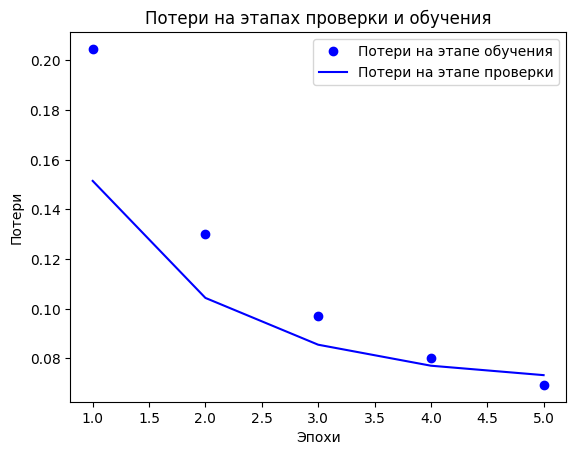

In [ ]:
history_dict = history.history
epochs = range(1, len(history_dict['loss'])+1)
plt.plot(epochs, history_dict['loss'], 'bo', label='Потери на этапе обучения')
plt.plot(epochs, history_dict['val_loss'], 'b', label='Потери на этапе проверки')
plt.title('Потери на этапах проверки и обучения')
plt.xlabel('Эпохи')
plt.ylabel('Потери')
plt.legend()
plt.show()

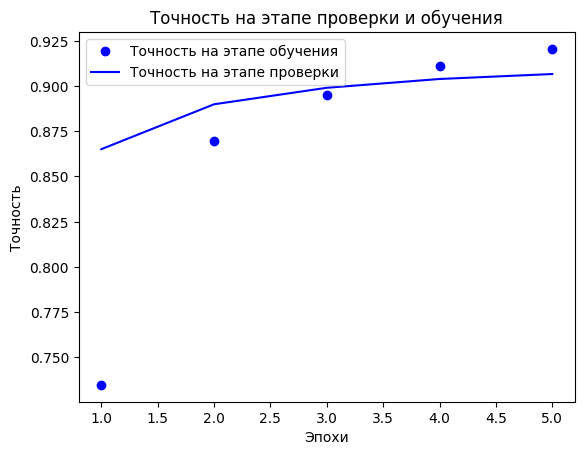

In [ ]:
plt.clf()
plt.plot(epochs, history_dict['accuracy'], 'bo', label='Точность на этапе обучения')
plt.plot(epochs, history_dict['val_accuracy'], 'b', label='Точность на этапе проверки')
plt.title('Точность на этапе проверки и обучения')
plt.xlabel('Эпохи')
plt.ylabel('Точность')
plt.legend()
plt.show()